# AI Job Market Salary Prediction

This project focuses on predicting annual salaries in the AI and technology job market using machine learning techniques.

The analysis begins with exploratory data analysis to understand the structure of the dataset, identify important patterns, examine relationships between features, and prepare the data for machine learning.

## Dataset Overview

The dataset is inspected to understand its dimensions, structure, missing values, duplicate records, and basic statistical characteristics.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# Basic information
print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Dataset Info ---")
print(df.info())


--- Dataset Shape ---
(1500, 25)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   str    
 1   job_title              1500 non-null   str    
 2   job_category           1500 non-null   str    
 3   experience_level       1500 non-null   str    
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   str    
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   str    
 10  country                1500 non-null   str    
 11  remote_work            1500 non-null   str    
 12  company_size           1500 non-null   str    
 13  industry               1500 non-null   str    
 14  required_sk

In [8]:
print(df["experience_level"].unique())
print(df["job_category"].unique())
print(
    df[df["country"] == "India"][
        [
            "city",
            "job_category",
            "experience_level",
            "years_of_experience",
            "annual_salary_usd"
        ]
    ].sort_values("annual_salary_usd").to_string(index=False)
)

<ArrowStringArray>
['Senior (6-9 yrs)', 'Lead (10+ yrs)', 'Entry (0-2 yrs)', 'Mid (3-5 yrs)']
Length: 4, dtype: str
<ArrowStringArray>
[  'AI Engineering', 'Data Engineering',          'Product',
         'Security',     'Architecture',    'ML Operations',
         'Business',         'Robotics',     'Data Science',
       'Governance',   'Infrastructure',         'Research']
Length: 12, dtype: str
     city     job_category experience_level  years_of_experience  annual_salary_usd
Bangalore   AI Engineering  Entry (0-2 yrs)                    1            90000.0
Bangalore         Business Senior (6-9 yrs)                    8            95000.0
Bangalore         Business    Mid (3-5 yrs)                    5            95000.0
Bangalore   AI Engineering    Mid (3-5 yrs)                    6           100000.0
Bangalore   AI Engineering Senior (6-9 yrs)                    4           100000.0
Bangalore   AI Engineering   Lead (10+ yrs)                    6           100000.0
Bangalore 

In [ ]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
      job_id           job_title      job_category  experience_level  \
0  AIJOB0001  AI Agent Developer    AI Engineering  Senior (6-9 yrs)   
1  AIJOB0002     Prompt Engineer    AI Engineering  Senior (6-9 yrs)   
2  AIJOB0003        LLM Engineer    AI Engineering  Senior (6-9 yrs)   
3  AIJOB0004  Data Engineer (AI)  Data Engineering  Senior (6-9 yrs)   
4  AIJOB0005  AI Product Manager           Product    Lead (10+ yrs)   

   years_of_experience    education_required  annual_salary_usd  \
0                    7              Master's           239000.0   
1                    2            Bachelor's           166000.0   
2                    4           Associate's           360000.0   
3                    3            Bachelor's           161000.0   
4                    5  Bootcamp/Self-taught           283000.0   

   salary_min_usd  salary_max_usd         city  ... ai_salary_premium_pct  \
0          155000          290000       Boston  ...              

In [10]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64


In [8]:
print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())


--- Duplicate Rows ---
0


In [9]:
print("\n--- Statistical Summary ---")
print(df.describe())


--- Statistical Summary ---
       years_of_experience  annual_salary_usd  salary_min_usd  salary_max_usd  \
count          1500.000000        1500.000000     1500.000000     1500.000000   
mean              6.216000      194892.000000   135448.666667   257537.333333   
std               2.675216       66506.822013    24448.950878    39852.822207   
min               1.000000       90000.000000    90000.000000   180000.000000   
25%               4.000000      144750.000000   120000.000000   218000.000000   
50%               6.000000      180000.000000   140000.000000   270000.000000   
75%               8.000000      236250.000000   155000.000000   290000.000000   
max              15.000000      384000.000000   180000.000000   320000.000000   

       ai_salary_premium_pct  demand_score  demand_growth_yoy_pct  \
count            1500.000000   1500.000000            1500.000000   
mean               10.858200     87.523333              31.116333   
std                 4.029742      

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of salaries and investigate relationships between salary and important job-related features such as job category, experience, education, required skills, remote work, and demand score.

### Salary Distribution Across Job Categories

A box plot is used to compare the distribution of annual salaries across different job categories. This helps identify differences in salary levels and the spread of salaries between categories.

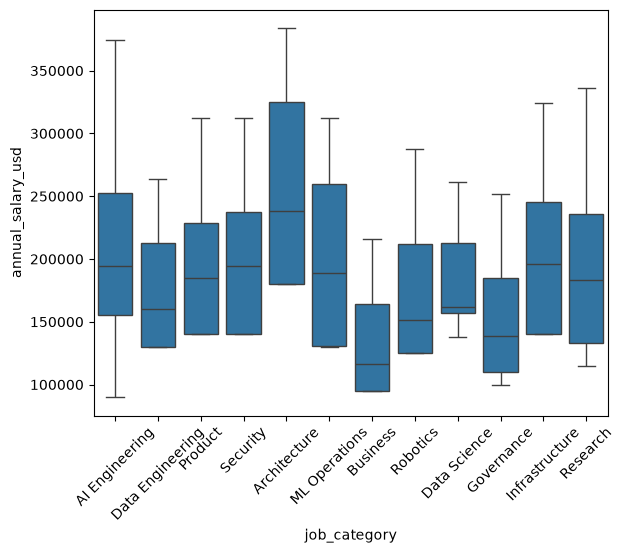

In [41]:
sns.boxplot(x="job_category",y="annual_salary_usd", data= df)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

### Years of Experience vs Annual Salary

The scatter plot examines the relationship between years of experience and annual salary. It helps determine whether salary tends to increase as professional experience increases.

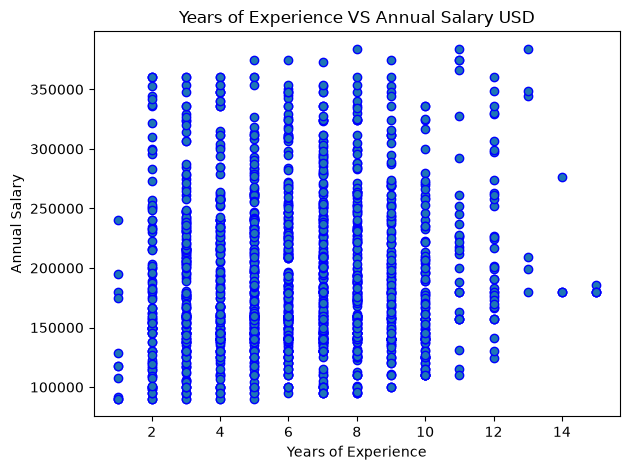

In [17]:
plt.scatter(x=df["years_of_experience"], y=df["annual_salary_usd"], edgecolors="blue")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary")
plt.title("Years of Experience VS Annual Salary USD")
plt.tight_layout()
plt.show()

In [ ]:
def split_values(values):
    return values.split("|")

df_copy = df.copy()
df_copy["required_skills"] = df_copy["required_skills"].apply(split_values)

In [ ]:
df_copy = df_copy.explode("required_skills")

total_skills = df_copy["required_skills"].value_counts()

required_skills
Python                     942
SQL                        452
Cloud                      429
Leadership                 380
Communication              378
                          ... 
OpenCV                      34
Risk Assessment             34
ETL                         33
Spark                       31
Enterprise Architecture     31
Name: count, Length: 93, dtype: int64

### Required Skills Analysis

The `required_skills` feature contains multiple skills for each job, separated by the `|` character. The values are split into individual skills and exploded so that each skill can be analyzed separately.

The most frequently occurring skills are then identified and their associated salary distributions are examined.

In [10]:
total_skills.head(10)

required_skills
Python             942
SQL                452
Cloud              429
Leadership         380
Communication      378
Research           376
Agile              351
Statistics         350
Linux              320
Problem Solving    314
Name: count, dtype: int64

In [36]:
top_skills = total_skills.head(10).index
top_skills

Index(['Python', 'SQL', 'Cloud', 'Leadership', 'Communication', 'Research',
       'Agile', 'Statistics', 'Linux', 'Problem Solving'],
      dtype='str', name='required_skills')

In [32]:
mask = df_copy["required_skills"].isin(top_skills)
mask

0       False
0       False
0        True
0        True
0        True
        ...  
1499     True
1499    False
1499     True
1499     True
1499     True
Name: required_skills, Length: 9548, dtype: bool

In [40]:
filtered_skills = df_copy[mask]
filtered_skills[["required_skills", "annual_salary_usd"]].head()

,required_skills,annual_salary_usd
0,Python,239000.0
0,Cloud,239000.0
0,SQL,239000.0
0,Leadership,239000.0
1,Python,166000.0


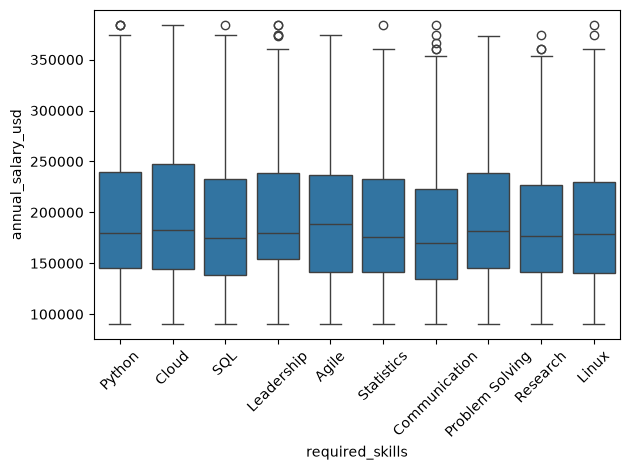

In [46]:
sns.boxplot(x="required_skills", y="annual_salary_usd", data= filtered_skills)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Salary Relationships with Other Job Characteristics

Additional categorical and numerical features are analyzed to understand their relationship with annual salary.

These include education requirements, experience level, company size, remote work arrangement, and demand score.

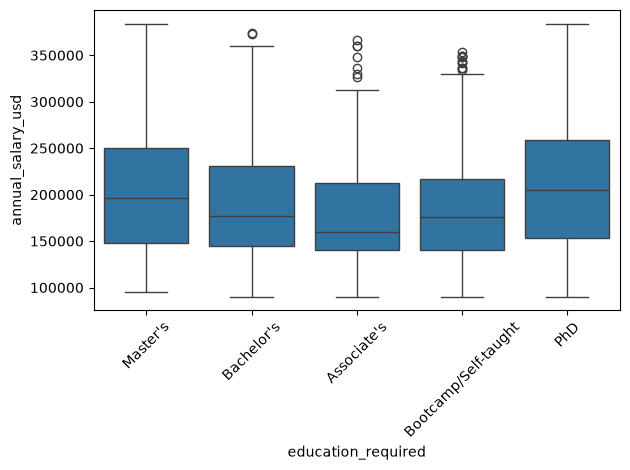

In [50]:
sns.boxplot(x="education_required", y="annual_salary_usd", data= df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

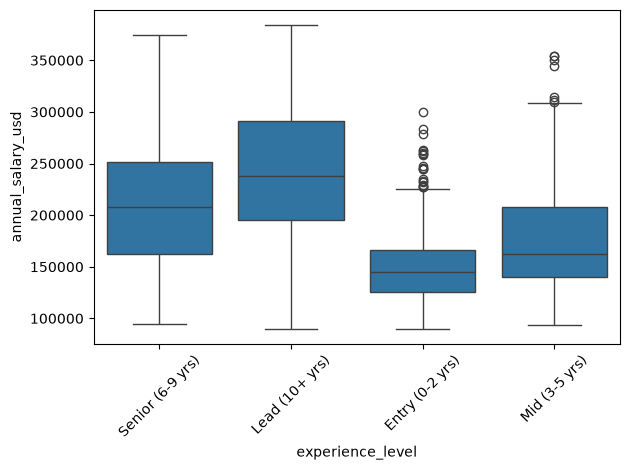

In [52]:
sns.boxplot(x="experience_level", y="annual_salary_usd", data= df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

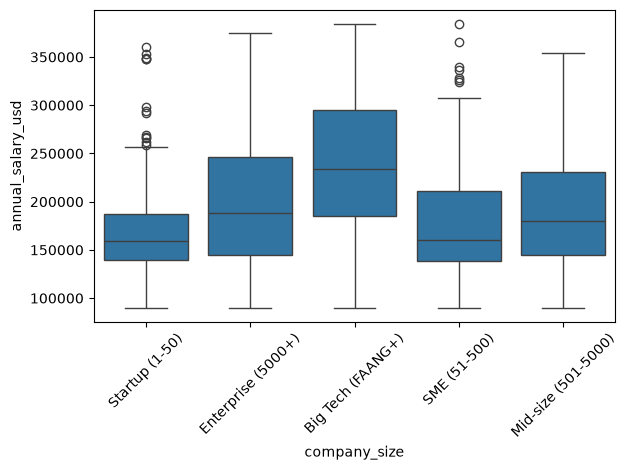

In [54]:
sns.boxplot(x="company_size", y="annual_salary_usd", data= df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

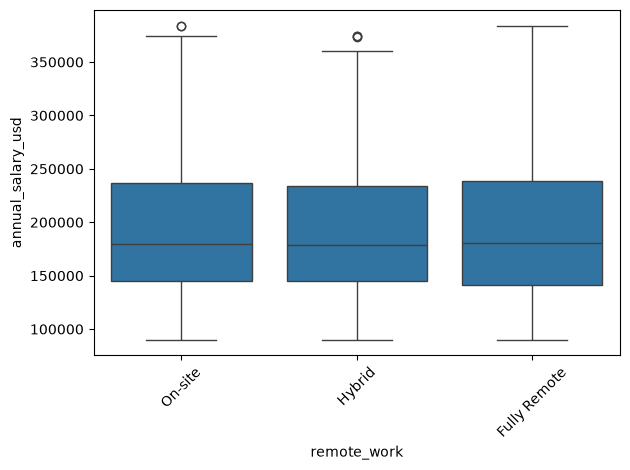

In [55]:
sns.boxplot(x="remote_work", y="annual_salary_usd", data= df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

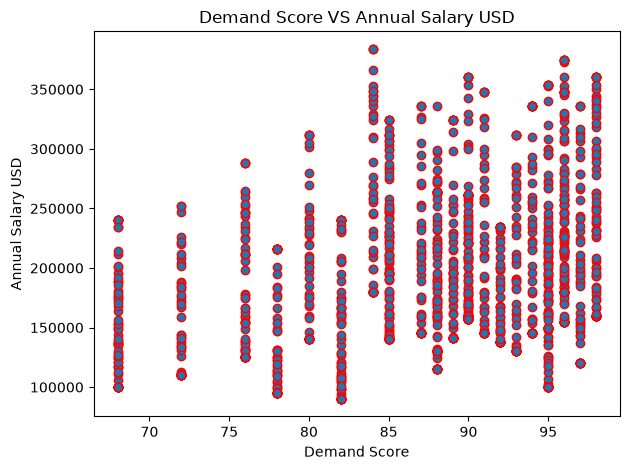

In [56]:
plt.scatter(x=df["demand_score"], y=df["annual_salary_usd"], edgecolors="red")
plt.xlabel("Demand Score")
plt.ylabel("Annual Salary USD")
plt.title("Demand Score VS Annual Salary USD")
plt.tight_layout()
plt.show()

### Salary Distribution

The distribution of annual salaries is examined using a histogram and descriptive statistics. This helps understand the central tendency, spread, and overall distribution of salary values.

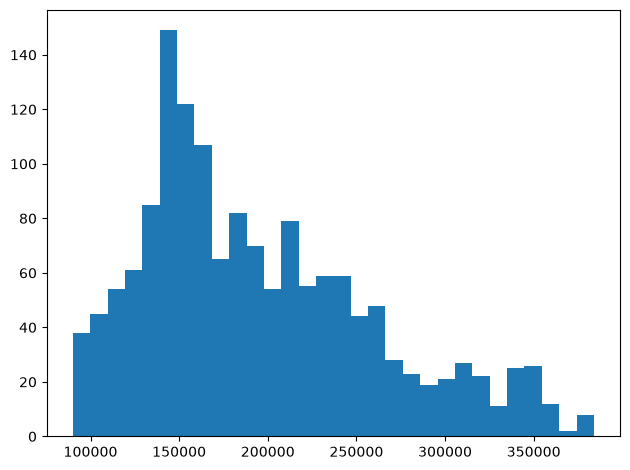

In [57]:
plt.hist(x=df["annual_salary_usd"], bins=30)
plt.tight_layout()
plt.show()

In [58]:
df["annual_salary_usd"].describe()

count      1500.000000
mean     194892.000000
std       66506.822013
min       90000.000000
25%      144750.000000
50%      180000.000000
75%      236250.000000
max      384000.000000
Name: annual_salary_usd, dtype: float64

### Correlation Analysis

Correlation between numerical variables is examined to identify linear relationships between features and annual salary.

A correlation heatmap is used to visualize these relationships.

In [72]:
num_columns = df.select_dtypes(include=["int64", "float64"])

correlation = num_columns.corr()

correlation

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
years_of_experience,1.000000,0.078643,0.251169,0.173499,0.138649,-0.096144,-0.121351,-0.036842,-0.002132,0.038534,0.007020,-0.004223,-0.375315
annual_salary_usd,0.078643,1.000000,0.421042,0.426631,-0.019829,0.291800,0.142776,-0.014715,0.022232,-0.024256,0.486629,-0.003238,0.102082
salary_min_usd,0.251169,0.421042,1.000000,0.742550,-0.076302,0.524296,0.182718,-0.008016,0.045599,-0.046918,0.018862,-0.037585,0.083787
salary_max_usd,0.173499,0.426631,0.742550,1.000000,0.081615,0.602882,0.299010,-0.004099,0.031210,-0.027242,0.016422,-0.049296,0.194550
ai_salary_premium_pct,0.138649,-0.019829,-0.076302,0.081615,1.000000,-0.189800,-0.084958,-0.025233,-0.039009,-0.013916,-0.012465,-0.036360,-0.248158
demand_score,-0.096144,0.291800,0.524296,0.602882,-0.189800,1.000000,0.565609,-0.001334,0.049317,-0.028512,0.048378,-0.023322,0.352338
demand_growth_yoy_pct,-0.121351,0.142776,0.182718,0.299010,-0.084958,0.565609,1.000000,-0.022552,0.060450,-0.008040,0.035933,-0.006263,0.301240
benefits_score_10,-0.036842,-0.014715,-0.008016,-0.004099,-0.025233,-0.001334,-0.022552,1.000000,-0.009402,-0.027583,0.003370,-0.011491,0.041699
posting_year,-0.002132,0.022232,0.045599,0.031210,-0.039009,0.049317,0.060450,-0.009402,1.000000,-0.701647,0.024130,0.007839,0.013208
posting_month,0.038534,-0.024256,-0.046918,-0.027242,-0.013916,-0.028512,-0.008040,-0.027583,-0.701647,1.000000,-0.004959,0.004352,-0.010636


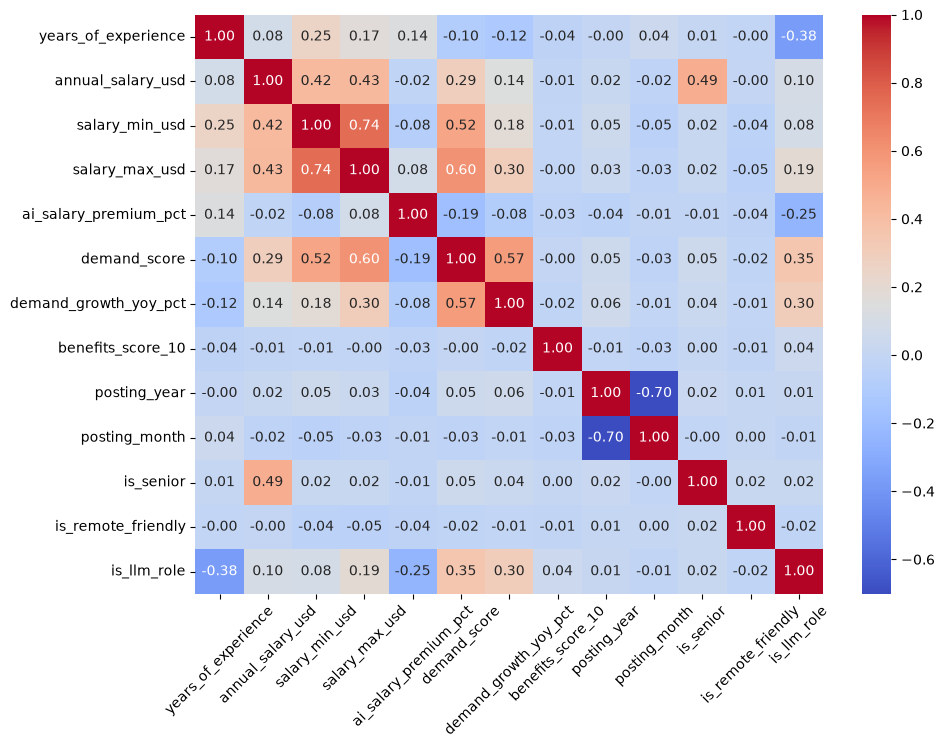

In [80]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm',fmt=".2f")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## Feature Engineering

Categorical variables cannot be directly used by most machine learning algorithms in their original text form. Therefore, categorical features are transformed using one-hot encoding.

One-hot encoding creates a separate binary feature for each category, allowing the machine learning models to process categorical information numerically.

In [5]:
df_encoded = pd.get_dummies(df, columns =["job_category","experience_level","education_required","city","country","remote_work"])

print(df_encoded.head(2))
print("\n" ,df_encoded.columns)

      job_id           job_title  years_of_experience  annual_salary_usd  \
0  AIJOB0001  AI Agent Developer                    7           239000.0   
1  AIJOB0002     Prompt Engineer                    2           166000.0   

   salary_min_usd  salary_max_usd        company_size industry  \
0          155000          290000      Startup (1-50)  Finance   
1           90000          200000  Enterprise (5000+)  Finance   

                                     required_skills  ai_salary_premium_pct  \
0  APIs|Planning Systems|Python|Cloud|SQL|Leadership                   13.1   
1  Python|Documentation|LLM APIs|Prompt Design|NL...                    5.4   

   ...  country_Japan  country_Netherlands  country_Singapore  \
0  ...          False                False              False   
1  ...          False                False              False   

   country_Switzerland  country_UAE  country_UK  country_USA  \
0                False        False       False         True   
1         

## Data Preparation

The dataset is prepared for machine learning by separating the target variable from the input features, removing identifiers and features that are not used for prediction, encoding the required skills, and constructing the final feature matrix.

The target variable is `annual_salary_usd`.

### Feature Construction

The selected categorical variables are one-hot encoded and combined with numerical features.

The `required_skills` column is transformed into multiple binary skill features. Since each job can contain multiple skills, the skill values are split, exploded, one-hot encoded, and grouped by the original job index using the maximum value. This results in one row per job with a binary indicator for each skill.

The resulting feature matrix is combined with the selected numerical and encoded categorical features to create `X_final`.

The dataset is then divided into training and testing sets using an 80:20 split. A fixed random state of 42 is used to ensure reproducibility.

In [22]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["job_id","job_title","annual_salary_usd","salary_min_usd","salary_max_usd","company_size","industry","ai_salary_premium_pct","posting_year","posting_month","is_senior","is_remote_friendly","salary_tier","required_skills","is_llm_role"])
y = df["annual_salary_usd"]

def split_values(values):
    return values.split("|")

required_skills = df["required_skills"].apply(split_values)

exploded_skills = required_skills.explode()

skills_encoded = pd.get_dummies(exploded_skills, columns=["required_skills"])

grouped_skills = skills_encoded.groupby(skills_encoded.index).max()

X_final = pd.concat([X, grouped_skills], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
        X_final, y, test_size=0.2, random_state=42, shuffle=True
    )

## Model 1: Linear Regression

Linear Regression is used as the baseline regression model. It provides a simple benchmark against which the more advanced tree-based models can be compared.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

model = LinearRegression()

model.fit(X_train, y_train)

# Make predictions
y_pred_lr = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
rmse = root_mean_squared_error(y_test, y_pred_lr)

# Print evaluation metrics
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 29971.23179324479
Mean Squared Error: 1430196540.0931401
R2 Score: 0.6510847518192641
Root Mean Squared Error: 37817.93939512226


## Model 2: Random Forest Regressor

Random Forest Regression is evaluated as a non-linear ensemble model. GridSearchCV with 5-fold cross-validation is used to search for suitable values of `max_depth` and `n_estimators`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

regr = RandomForestRegressor(random_state=42)

parameter_grid ={
    "max_depth":[5, 10 , 15],
    "n_estimators":[100,200,300]
}

grid_search = GridSearchCV(estimator=regr, param_grid=parameter_grid, scoring='neg_mean_absolute_error', cv=5, refit=True)

grid_search.fit(X_train,y_train)

best_model = grid_search.best_estimator_

y_pred_rf = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = root_mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Best Parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
print(f"Root Mean Squared Error: {rmse}")

Best Parameters: {'max_depth': 15, 'n_estimators': 100}
Best CV MAE: 28494.618585472053
Mean Absolute Error: 26658.84162031909
Mean Squared Error: 1274674627.4027922
R2 Score: 0.6890263670047976
Root Mean Squared Error: 35702.58572432524


## Model 3: XGBoost Regressor

XGBoost is evaluated as a gradient-boosting regression model. GridSearchCV with 5-fold cross-validation is used to tune the number of estimators, maximum tree depth, and learning rate.

The model with the best cross-validation performance is then refitted using the training data and evaluated on the held-out test set.

In [30]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

parameter_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=parameter_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=5,
    refit=True
)

grid_search_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_search_xgb.best_params_)
print("Best CV MAE:", -grid_search_xgb.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best CV MAE: 26361.389641927082


In [31]:
best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb}")
print(f"XGBoost MSE: {mse_xgb}")
print(f"XGBoost RMSE: {rmse_xgb}")
print(f"XGBoost R2: {r2_xgb}")

XGBoost MAE: 25236.768619791666
XGBoost MSE: 1077625557.0528595
XGBoost RMSE: 32827.207573183245
XGBoost R2: 0.7370990782424102


## Model Performance Comparison

Three regression models were evaluated for the annual salary prediction task:

1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

For MAE and RMSE, lower values indicate better performance, while a higher R² Score indicates better explanatory performance.

In [37]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        29971.23179324479,
        26658.84162031909,
        25236.768619791666
    ],
    "RMSE": [
        37817.93939512226,
        35702.58572432524,
        32827.207573183245
    ],
    "R2 Score": [
        0.6510847518192641,
        0.6890263670047976,
        0.7370990782424102
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,29971.231793,37817.939395,0.651085
1,Random Forest,26658.841620,35702.585724,0.689026
2,XGBoost,25236.768620,32827.207573,0.737099


### Comparison of Results

The comparison shows that XGBoost achieved the best performance across all three evaluation metrics. It obtained the lowest MAE and RMSE and the highest R² Score.

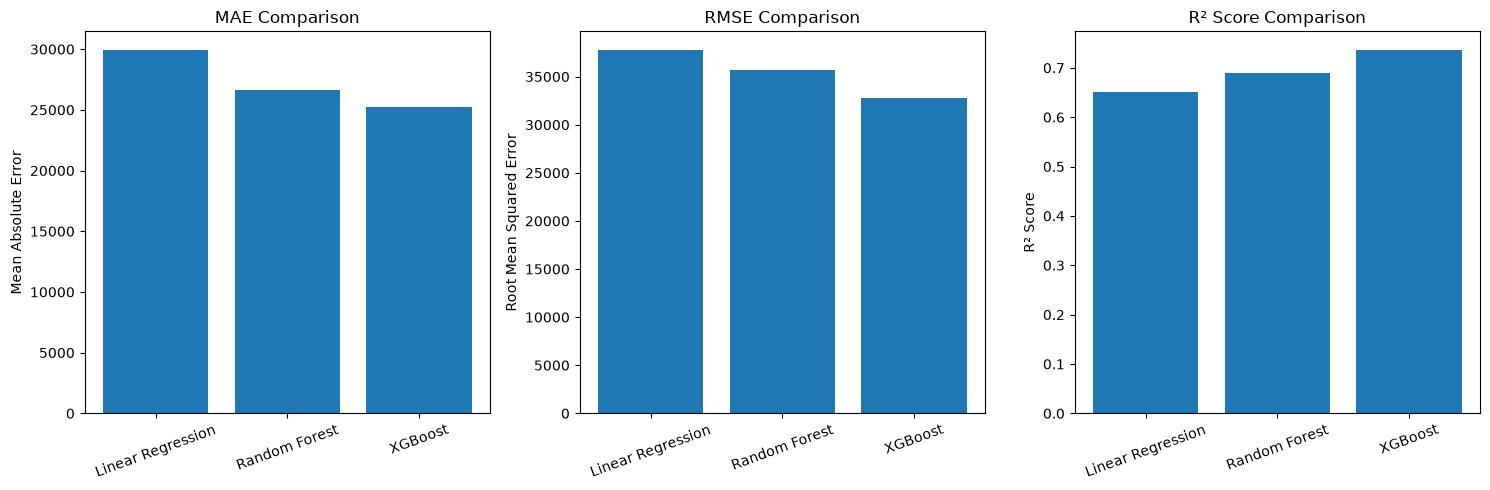

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = model_comparison["Model"]

axes[0].bar(models, model_comparison["MAE"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("Mean Absolute Error")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(models, model_comparison["RMSE"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("Root Mean Squared Error")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(models, model_comparison["R2 Score"])
axes[2].set_title("R² Score Comparison")
axes[2].set_ylabel("R² Score")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Model Selection

Based on the test-set evaluation, XGBoost achieved the best overall performance among the three evaluated models.

It obtained the lowest Mean Absolute Error and Root Mean Squared Error, along with the highest R² Score.

Therefore, XGBoost was selected as the final model for the salary prediction system.

The final XGBoost model achieved:

- **MAE:** $25,236.77
- **RMSE:** $32,827.21
- **R² Score:** 0.7371

The model was selected based on its performance on the held-out test dataset.

## Final Model Evaluation

XGBoost was selected as the final regression model based on its superior performance compared with Linear Regression and Random Forest.

The following analysis examines the prediction behavior of the final XGBoost model using an Actual vs Predicted Salary plot.

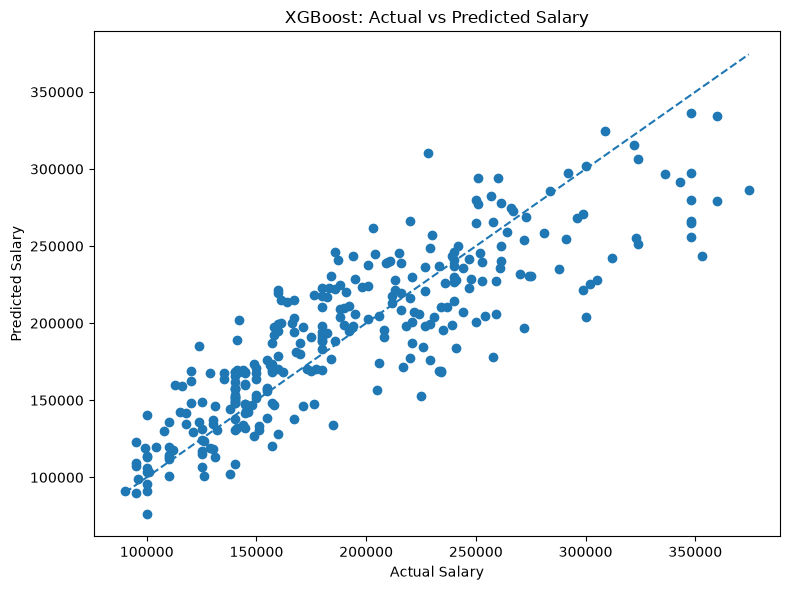

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_xgb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("XGBoost: Actual vs Predicted Salary")

plt.tight_layout()
plt.show()

### Interpretation

The Actual vs Predicted Salary plot shows a clear positive relationship between actual and predicted salaries. Many predictions lie reasonably close to the diagonal reference line, indicating that the model is able to capture a substantial portion of the salary variation.

The model shows greater dispersion at higher salary levels, indicating that predicting extreme salaries is more difficult. Points above the diagonal represent overpredictions, while points below the diagonal represent underpredictions.

## Feature Importance Analysis

Feature importance is used to identify the features that were most useful to the final XGBoost model when making salary predictions.

The analysis does not imply that a feature causes salary to increase or decrease. Instead, it indicates the relative contribution of features to the model's predictive decisions.

In [40]:
feature_importance_xgb = best_xgb.feature_importances_

importance_xgb_df = pd.DataFrame({
    "feature": X_final.columns,
    "importance": feature_importance_xgb
})

importance_xgb_df = importance_xgb_df.sort_values(
    by="importance",
    ascending=False
)

importance_xgb_df.head(15)

,feature,importance
17,experience_level_Lead (10+ yrs),0.068633
58,country_USA,0.061486
1,demand_score,0.058324
19,experience_level_Senior (6-9 yrs),0.047480
28,city_Beijing,0.044545
16,experience_level_Entry (0-2 yrs),0.043754
4,job_category_AI Engineering,0.038195
97,Fine-tuning,0.037001
27,city_Bangalore,0.033182
146,System Design,0.030499


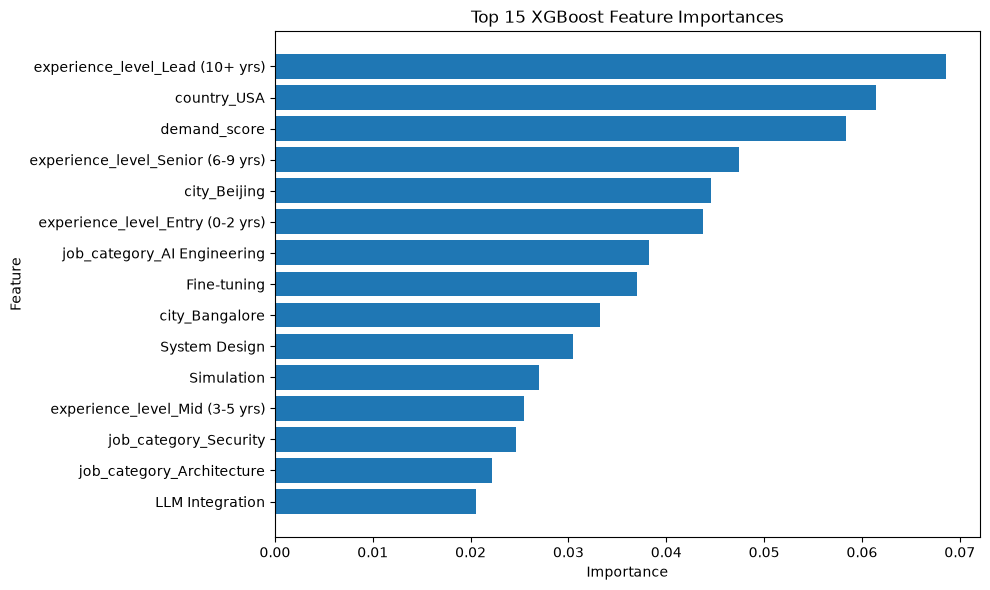

In [41]:
top_features_xgb = importance_xgb_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_xgb["feature"],
    top_features_xgb["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretation

The feature importance analysis shows that experience level, geographic location, job demand, job category, and specialized technical skills are among the most influential features used by the XGBoost model.

The most influential individual features include experience level indicators, country_USA, demand_score, city_Beijing, job category indicators, Fine-tuning, System Design, Simulation, and LLM Integration.

These results indicate that the model uses a combination of professional experience, geographical factors, market demand, job category, and technical skills when predicting annual salary.

## Saving the Final Model

The tuned XGBoost model selected through cross-validation is saved using Joblib so that it can be reused later without retraining the model.

The final feature-column structure and skill-column structure are also saved because they are required to prepare new input data in the same format used during model training.

In [44]:
import joblib

joblib.dump(best_xgb, "salary_model.pkl")
joblib.dump(X_final.columns.tolist(), "feature_columns.pkl")
joblib.dump(grouped_skills.columns.tolist(), "skill_columns.pkl")

print("Final model and feature information saved successfully.")

Final model and feature information saved successfully.


## Conclusion

This project developed a machine learning-based system for predicting annual salaries in the AI and technology job market.

The dataset was explored and relevant features were selected and transformed into a machine-learning-ready format. Categorical variables were encoded using appropriate encoding techniques, while the multiple skills associated with each job were transformed into individual binary skill features.

Three regression models were evaluated: Linear Regression, Random Forest, and XGBoost. Cross-validation and GridSearchCV were used to tune the tree-based models while keeping the test dataset separate from the model-selection process.

Among the evaluated models, XGBoost achieved the best performance with a Mean Absolute Error of approximately $25,237, a Root Mean Squared Error of approximately $32,827, and an R² Score of 0.7371.

Therefore, the tuned XGBoost model was selected as the final model for the salary prediction system.

The Actual vs Predicted analysis showed a clear positive relationship between actual and predicted salaries, although prediction errors increased for some higher salary values. Feature importance analysis further showed that experience level, location, demand, job category, and specialized technical skills were important inputs for the final model.